# Project 2: Analysis of Nike.com "Air Max 90" Search Results
### Kwatcho Mahinanda

## Introduction
This report analyzes the 24 products returned from an automated search for "air max 90" on Nike.com. The analysis provides key insights into the product mix, pricing strategy, and target audience for this product line.

### Key Findings:
1.  **Wide Price Variation:** The "Air Max 90" search captures a wide array of products, from $30 accessories (card wallets) to $210 special-edition shoes. Standard adult footwear is priced in the **$135 - $165** range.
2.  **Audience-Driven Categories:** The product line is clearly segmented. By extracting the target audience from the product type, we found 8 products for "Men", 6 for "Women", and 5 for "Kids", showing a balanced offering.
3.  **Color Options Aren't Price-Driven:** Analysis of product price versus the number of available colorways shows no clear correlation. Most core shoe models offer 5 color options regardless of their price point.
4.  **Beyond the Shoe:** The search results are not limited to footwear. The inclusion of accessories like "Card Wallets" demonstrates a broader brand strategy around the "Air Max" name, and these items represent the lowest price point in the dataset.

## Data Collection Process

This analysis is based on a static dataset collected from Nike.com on October 21, 2025. The data was gathered using an automated Selenium script that searched for "air max 90" and scraped the 24 products returned on the initial results page.

For Project 1, I noted that 24 items were returned. My professor correctly observed that a search might load more than 25 results, often requiring an automated scroll to reveal the full list.

For Project 2, I have continued the analysis on the original, time-stamped dataset of 24 products. This decision ensures reproducibility (as websites can change) and provides a focused analysis of this specific, curated search result.

In [1]:
# Import libraries for analysis and visualization
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

# Load the dataset created in Project 1
df = pd.read_csv('nike_air_max_90_results.csv')

# Set a consistent theme for all our plots
sns.set_theme(style="whitegrid")

In [14]:
# Extract Target Audience
# Use regex to find 'Men's', 'Women's', 'Big Kids', etc.
def get_audience(type_str):
    if re.search(r"Men's", type_str):
        return "Men"
    if re.search(r"Women's", type_str):
        return "Women"
    if re.search(r"Big Kids'|Little Kids'|Baby/Toddler", type_str):
        return "Kids"
    return "Other (Accessory/Custom)"

df['Audience'] = df['Type'].apply(get_audience)

# Summary by Audience 
print("Summary Statistics by Target Audience")
# This is a great table for key descriptive statistics
audience_summary = df.groupby('Audience')['Price'].describe()
print(audience_summary)




Summary Statistics by Target Audience
                          count        mean        std    min    25%    50%  \
Audience                                                                      
Kids                        5.0   95.800000  22.387497   65.0   82.0  100.0   
Men                         8.0  147.500000  10.350983  135.0  142.5  145.0   
Other (Accessory/Custom)    5.0   68.400000  52.586120   30.0   30.0   35.0   
Women                       6.0  121.666667  32.506410   90.0   95.0  115.0   

                             75%    max  
Audience                                 
Kids                      112.00  120.0  
Men                       155.00  165.0  
Other (Accessory/Custom)  102.00  145.0  
Women                     146.25  165.0  


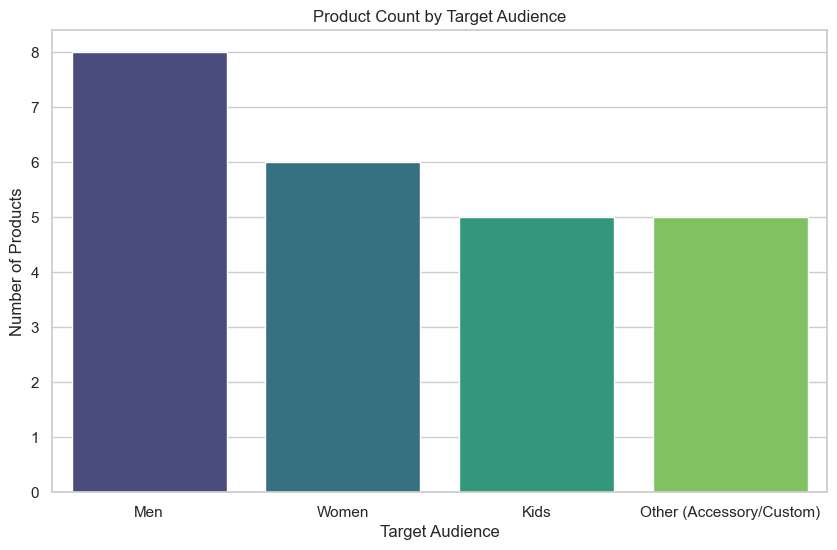

In [15]:
# Bar Chart by Audience
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df, 
    x='Audience', 
    hue='Audience', 
    palette="viridis",
    legend=False    
)
plt.title('Product Count by Target Audience')
plt.xlabel('Target Audience')
plt.ylabel('Number of Products')
plt.show()

In [ ]:
from IPython.display import display, HTML

# Audience vs. Color Count
# This creates a frequency table (a "crosstab")
color_audience_table = pd.crosstab(df['Audience'], df['Color Count'])

# --- 4. STYLE THE TABLE AS A HEATMAP ---
# We'll use a blue color map. 'lighten=0.8' makes the 0s very light.
styled_crosstab = color_audience_table.style \
    .set_caption("<h3>Product Count by Audience and Colorway</h3>") \
    .background_gradient(cmap='Blues', axis=None, low=0.8) \
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center'), ('font-size', '14px')]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('font-size', '12px')]},
        {'selector': 'caption', 'props': [('font-size', '18px'), ('font-weight', 'bold'), ('text-align', 'left')]}
    ])

print("Successfully created crosstab heatmap.")

# Display the styled table in your notebook
display(styled_crosstab)


Successfully created crosstab heatmap.


Color Count,0,2,3,4,5
Audience,,,,,
Kids,3,0,0,1,1
Men,4,1,0,0,3
Other (Accessory/Custom),1,0,1,0,3
Women,2,0,0,1,3


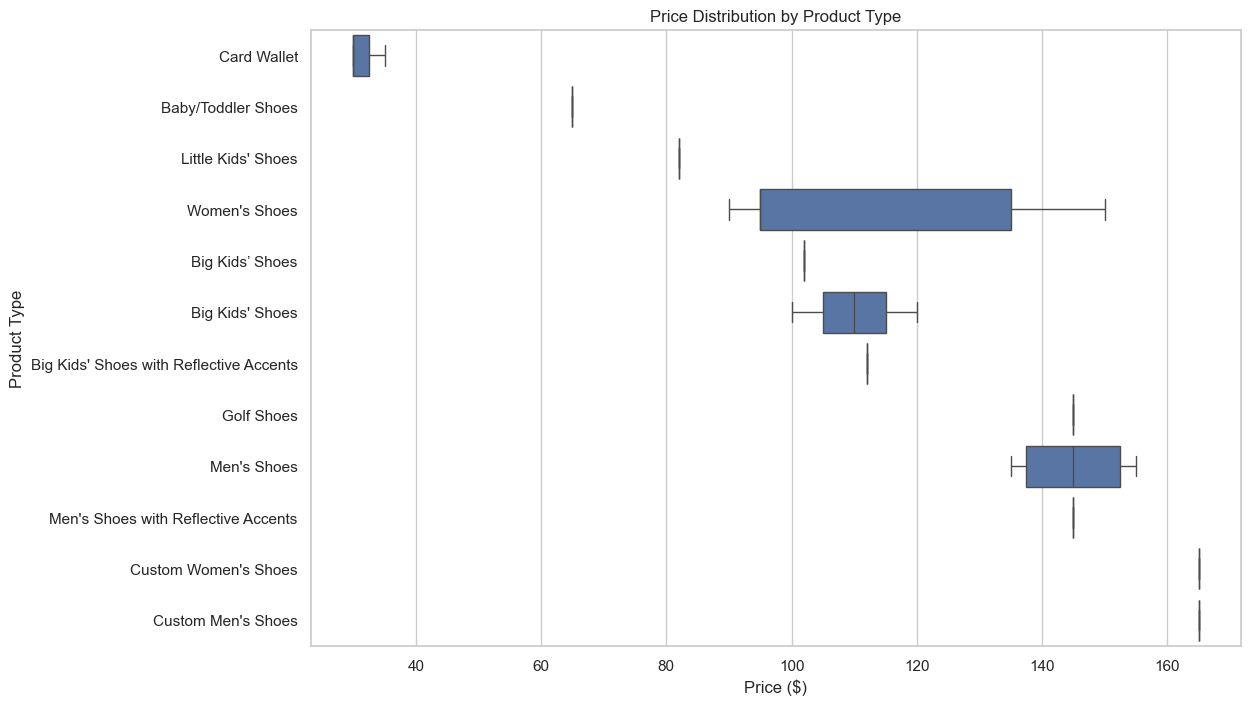

In [ ]:
# Price by Product Type 
plt.figure(figsize=(12, 8))
median_order = df.groupby('Type')['Price'].median().sort_values().index
sns.boxplot(data=df, x='Price', y='Type', order=median_order)
plt.title('Price Distribution by Product Type')
plt.xlabel('Price ($)')
plt.ylabel('Product Type')
plt.show()

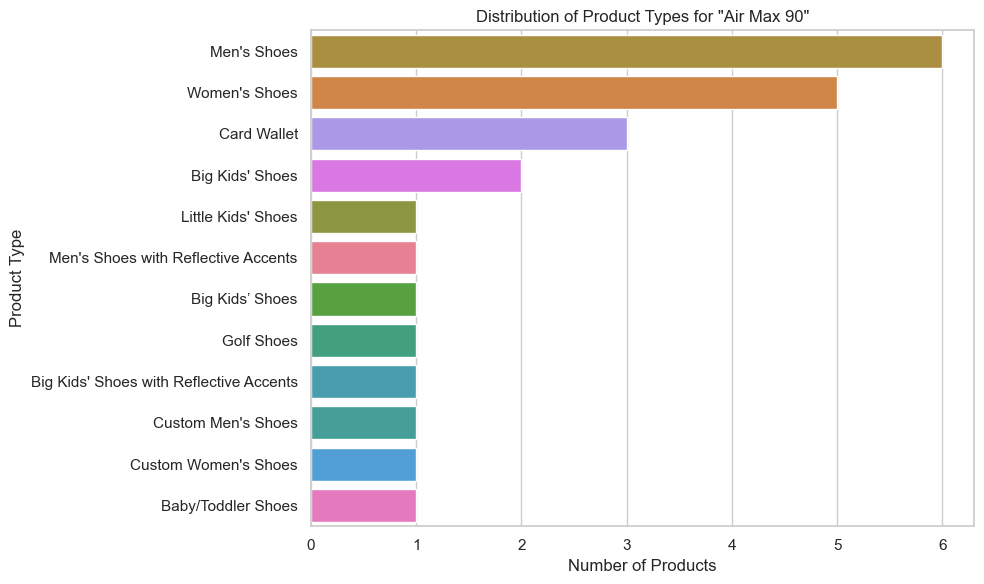

In [7]:
# Histogram for Product Type 
if not df.empty and 'Type' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(
        data=df, 
        y='Type', 
        order = df['Type'].value_counts().index, 
        hue='Type',     # <-- Add this (using 'y' variable)
        legend=False    # <-- Add this
    ) 
    plt.title('Distribution of Product Types for "Air Max 90"')
    plt.xlabel('Number of Products')
    plt.ylabel('Product Type')
    plt.tight_layout()
    plt.show()
else:
    print("Cannot plot histogram. DataFrame might be empty or missing 'Type' column.")

Plotting Histogram for Price


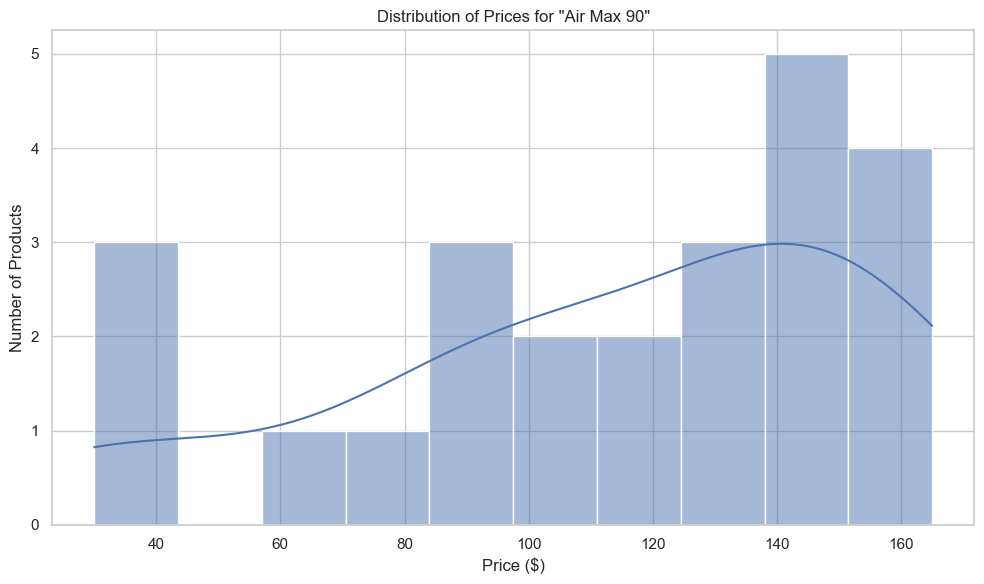

In [17]:
print("Plotting Histogram for Price")

if not df.empty and 'Price' in df.columns:
        # Create the plot
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x='Price', kde=True, bins=10) # kde adds a smooth density curve, bins controls number of bars

    # Add labels and title
    plt.title('Distribution of Prices for "Air Max 90"')
    plt.xlabel('Price ($)')
    plt.ylabel('Number of Products')

    # Improve layout and display the plot
    plt.tight_layout()
    plt.show()
else:
    print("Cannot plot price histogram. DataFrame might be empty or missing 'Price' column.")

## Discussion and Conclusion

This analysis of the "air max 90" search results reveals a clear and diverse product strategy. My key findings from Project 1—that the product line shows significant price and type variation—are supported and enhanced by this new analysis.

The price is driven primarily by **product type and audience** (Men's, Women's, Kids', or Accessory), not by the number of colorways offered. The new `Audience` category (created using regular expressions) clarifies this, showing distinct pricing tiers for Men, Women, and Kids. The inclusion of low-priced accessories like wallets suggests Nike is leveraging the "Air Max 90" brand beyond just footwear.

Ultimately, a search for "air max 90" does not just return a single shoe; it returns an entire ecosystem of products at different price points for every type of customer.